<a href="https://colab.research.google.com/github/Nanase1994/BA820-Unsupervised-and-Unstructured-Machine-Learning-Project-/blob/main/Kang_M4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#820_Pet_Cats_in_the_UK_M3_Integrated

---



**Section B Team 12**

**Group Member; Kaixin Gao, Kang Ni, Xiaoyan Wang, Fei Han**

##Dataset Selection & Understanding

##Domain & Context

The Pet Cats UK dataset comes from the Movebank for Animal Tracking Data and contains high-resolution GPS tracking and metadata for domestic cats in the United Kingdom between 2013 and 2017. Cats were fitted with GPS collars, generating time-stamped location pings that capture fine-grained living habit within and beyond home environments. In addition to spatial trajectories, the dataset includes cat-level characteristics such as age, sex, neuter status, and hunting behavior.

###Motivation

Pet cats are widely distributed across urban areas, yet their living habit is often treated as homogeneous despite growing evidence of substantial individual variation. Analysis of the Pet Cats UK dataset shows that while most cats remain close to their homes, a small subset exhibits irregular living habit. Understanding these differences is important because cats’ movement behaviors directly influence ecological impacts, exposure to risk, and interactions with humans and the urban environment. By identifying distinct movement patterns among urban pet cats, this project aims to support more targeted and evidence-based decision-making for conservation groups, policymakers, and pet owners.

###Stakeholders & Decision-Makers



*   Urban planners and local councils
*   veterinarian

*   Pet owner

*  Urban biodiversity–focused conservation organizations
*   Ecologist






###Data Insights

###Data Import and Preparation

In [ ]:
import pandas as pd
import numpy as np

cats_gps_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk.csv"
cats_meta_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk_reference.csv"
cats_gps = pd.read_csv(cats_gps_url)
cats_meta = pd.read_csv(cats_meta_url)
print("GPS dataset shape:", cats_gps.shape)
print("Metadata dataset shape:", cats_meta.shape)

cats_gps.head(), cats_meta.head()

GPS dataset shape: (18215, 11)
Metadata dataset shape: (101, 16)


(  tag_id    event_id  visible             timestamp  location_long  \
 0   Ares  3395610551     True  2017-06-24T01:03:57Z      -5.113851   
 1   Ares  3395610552     True  2017-06-24T01:11:20Z      -5.113851   
 2   Ares  3395610553     True  2017-06-24T02:58:16Z      -5.113730   
 3   Ares  3395610554     True  2017-06-24T03:01:26Z      -5.113774   
 4   Ares  3395610555     True  2017-06-24T03:51:58Z      -5.114247   
 
    location_lat  ground_speed  height_above_ellipsoid  \
 0     50.170315           684                  154.67   
 1     50.170315           936                  154.67   
 2     50.169876          2340                   81.35   
 3     50.169827             0                   67.82   
 4     50.170139          4896                  118.03   
 
    algorithm_marked_outlier  manually_marked_outlier               study_name  
 0                     False                    False  Pet Cats United Kingdom  
 1                     False                    False  Pet C

**Dataset Size & Structure**

**Pet Cats UK (GPS records)**

row: 18,215

column: 11

Description: Time-stamped GPS location data; multiple records per cat capturing movement trajectories。

**Pet Cats UK (Cat metadata)**

row:101

column:16

Description: Cat-level attributes such as age, sex, neuter status, and hunting behavior



**Data Type:**

Pet Cats UK (GPS records)


In [ ]:
display(cats_gps.dtypes)

tag_id                          str
event_id                      int64
visible                        bool
timestamp                       str
location_long               float64
location_lat                float64
ground_speed                  int64
height_above_ellipsoid      float64
algorithm_marked_outlier       bool
manually_marked_outlier        bool
study_name                      str
dtype: object

Pet Cats UK (Cat metadata)


In [ ]:
display(cats_meta.dtypes)

tag_id                               str
animal_id                            str
animal_taxon                         str
deploy_on_date                       str
deploy_off_date                      str
hunt                              object
prey_p_month                     float64
animal_reproductive_condition        str
animal_sex                           str
hrs_indoors                      float64
n_cats                             int64
food_dry                            bool
food_wet                            bool
food_other                        object
study_site                           str
age_years                        float64
dtype: object

##EDA

In [ ]:
print(cats_gps.info())
print(cats_meta.info())

<class 'pandas.DataFrame'>
RangeIndex: 18215 entries, 0 to 18214
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tag_id                    18215 non-null  str    
 1   event_id                  18215 non-null  int64  
 2   visible                   18215 non-null  bool   
 3   timestamp                 18215 non-null  str    
 4   location_long             18215 non-null  float64
 5   location_lat              18215 non-null  float64
 6   ground_speed              18215 non-null  int64  
 7   height_above_ellipsoid    18215 non-null  float64
 8   algorithm_marked_outlier  18215 non-null  bool   
 9   manually_marked_outlier   18215 non-null  bool   
 10  study_name                18215 non-null  str    
dtypes: bool(3), float64(3), int64(2), str(3)
memory usage: 1.2 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 16 columns):
 #   Column          

In [ ]:
full_cats_data = cats_gps.merge(
    cats_meta,
    on='tag_id',
    how='left'
)
full_cats_data

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,...,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,food_other,study_site,age_years
0,Ares,3395610551,True,2017-06-24T01:03:57Z,-5.113851,50.170315,684,154.67,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
1,Ares,3395610552,True,2017-06-24T01:11:20Z,-5.113851,50.170315,936,154.67,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
2,Ares,3395610553,True,2017-06-24T02:58:16Z,-5.113730,50.169876,2340,81.35,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
3,Ares,3395610554,True,2017-06-24T03:01:26Z,-5.113774,50.169827,0,67.82,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
4,Ares,3395610555,True,2017-06-24T03:51:58Z,-5.114247,50.170139,4896,118.03,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18210,Millie-Tag,4149497976,True,2017-11-26T15:37:52Z,-4.521489,50.869320,1260,144.66,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0
18211,Millie-Tag,4149497977,True,2017-11-26T15:40:59Z,-4.521498,50.869289,16380,136.60,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0
18212,Millie-Tag,4149497978,True,2017-11-26T16:27:31Z,-4.521803,50.869438,4500,160.97,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0
18213,Millie-Tag,4149497979,True,2017-11-26T16:34:26Z,-4.521946,50.869392,1044,179.81,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0


In [ ]:
cleaned_cats_data = full_cats_data[~full_cats_data['tag_id'].isin(['Ares', 'Wilfred-Tag', 'Lightening Bugg-Tag', 'Jezebel-Tag','Tipsy-Tag','Maggie-Tag','Lily-Tag','Pants-Tag','Neil-Tag','Johnny-Tag','Meg-Tag','Amber-Tag','Charlie3-Tag'])]
cleaned_cats_data = cleaned_cats_data.drop('food_other', axis=1)
cleaned_cats_data

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,...,hunt,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,study_site,age_years
103,Athena,3395610893,True,2017-06-24T01:02:13Z,-5.114018,50.170296,360,78.04,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
104,Athena,3395610894,True,2017-06-24T01:05:33Z,-5.113985,50.170277,828,70.43,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
105,Athena,3395610895,True,2017-06-24T02:12:30Z,-5.114270,50.170177,288,65.66,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
106,Athena,3395610896,True,2017-06-24T02:15:29Z,-5.114331,50.170170,0,75.44,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
107,Athena,3395610897,True,2017-06-24T05:30:58Z,-5.114207,50.170303,792,68.41,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18210,Millie-Tag,4149497976,True,2017-11-26T15:37:52Z,-4.521489,50.869320,1260,144.66,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18211,Millie-Tag,4149497977,True,2017-11-26T15:40:59Z,-4.521498,50.869289,16380,136.60,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18212,Millie-Tag,4149497978,True,2017-11-26T16:27:31Z,-4.521803,50.869438,4500,160.97,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18213,Millie-Tag,4149497979,True,2017-11-26T16:34:26Z,-4.521946,50.869392,1044,179.81,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0


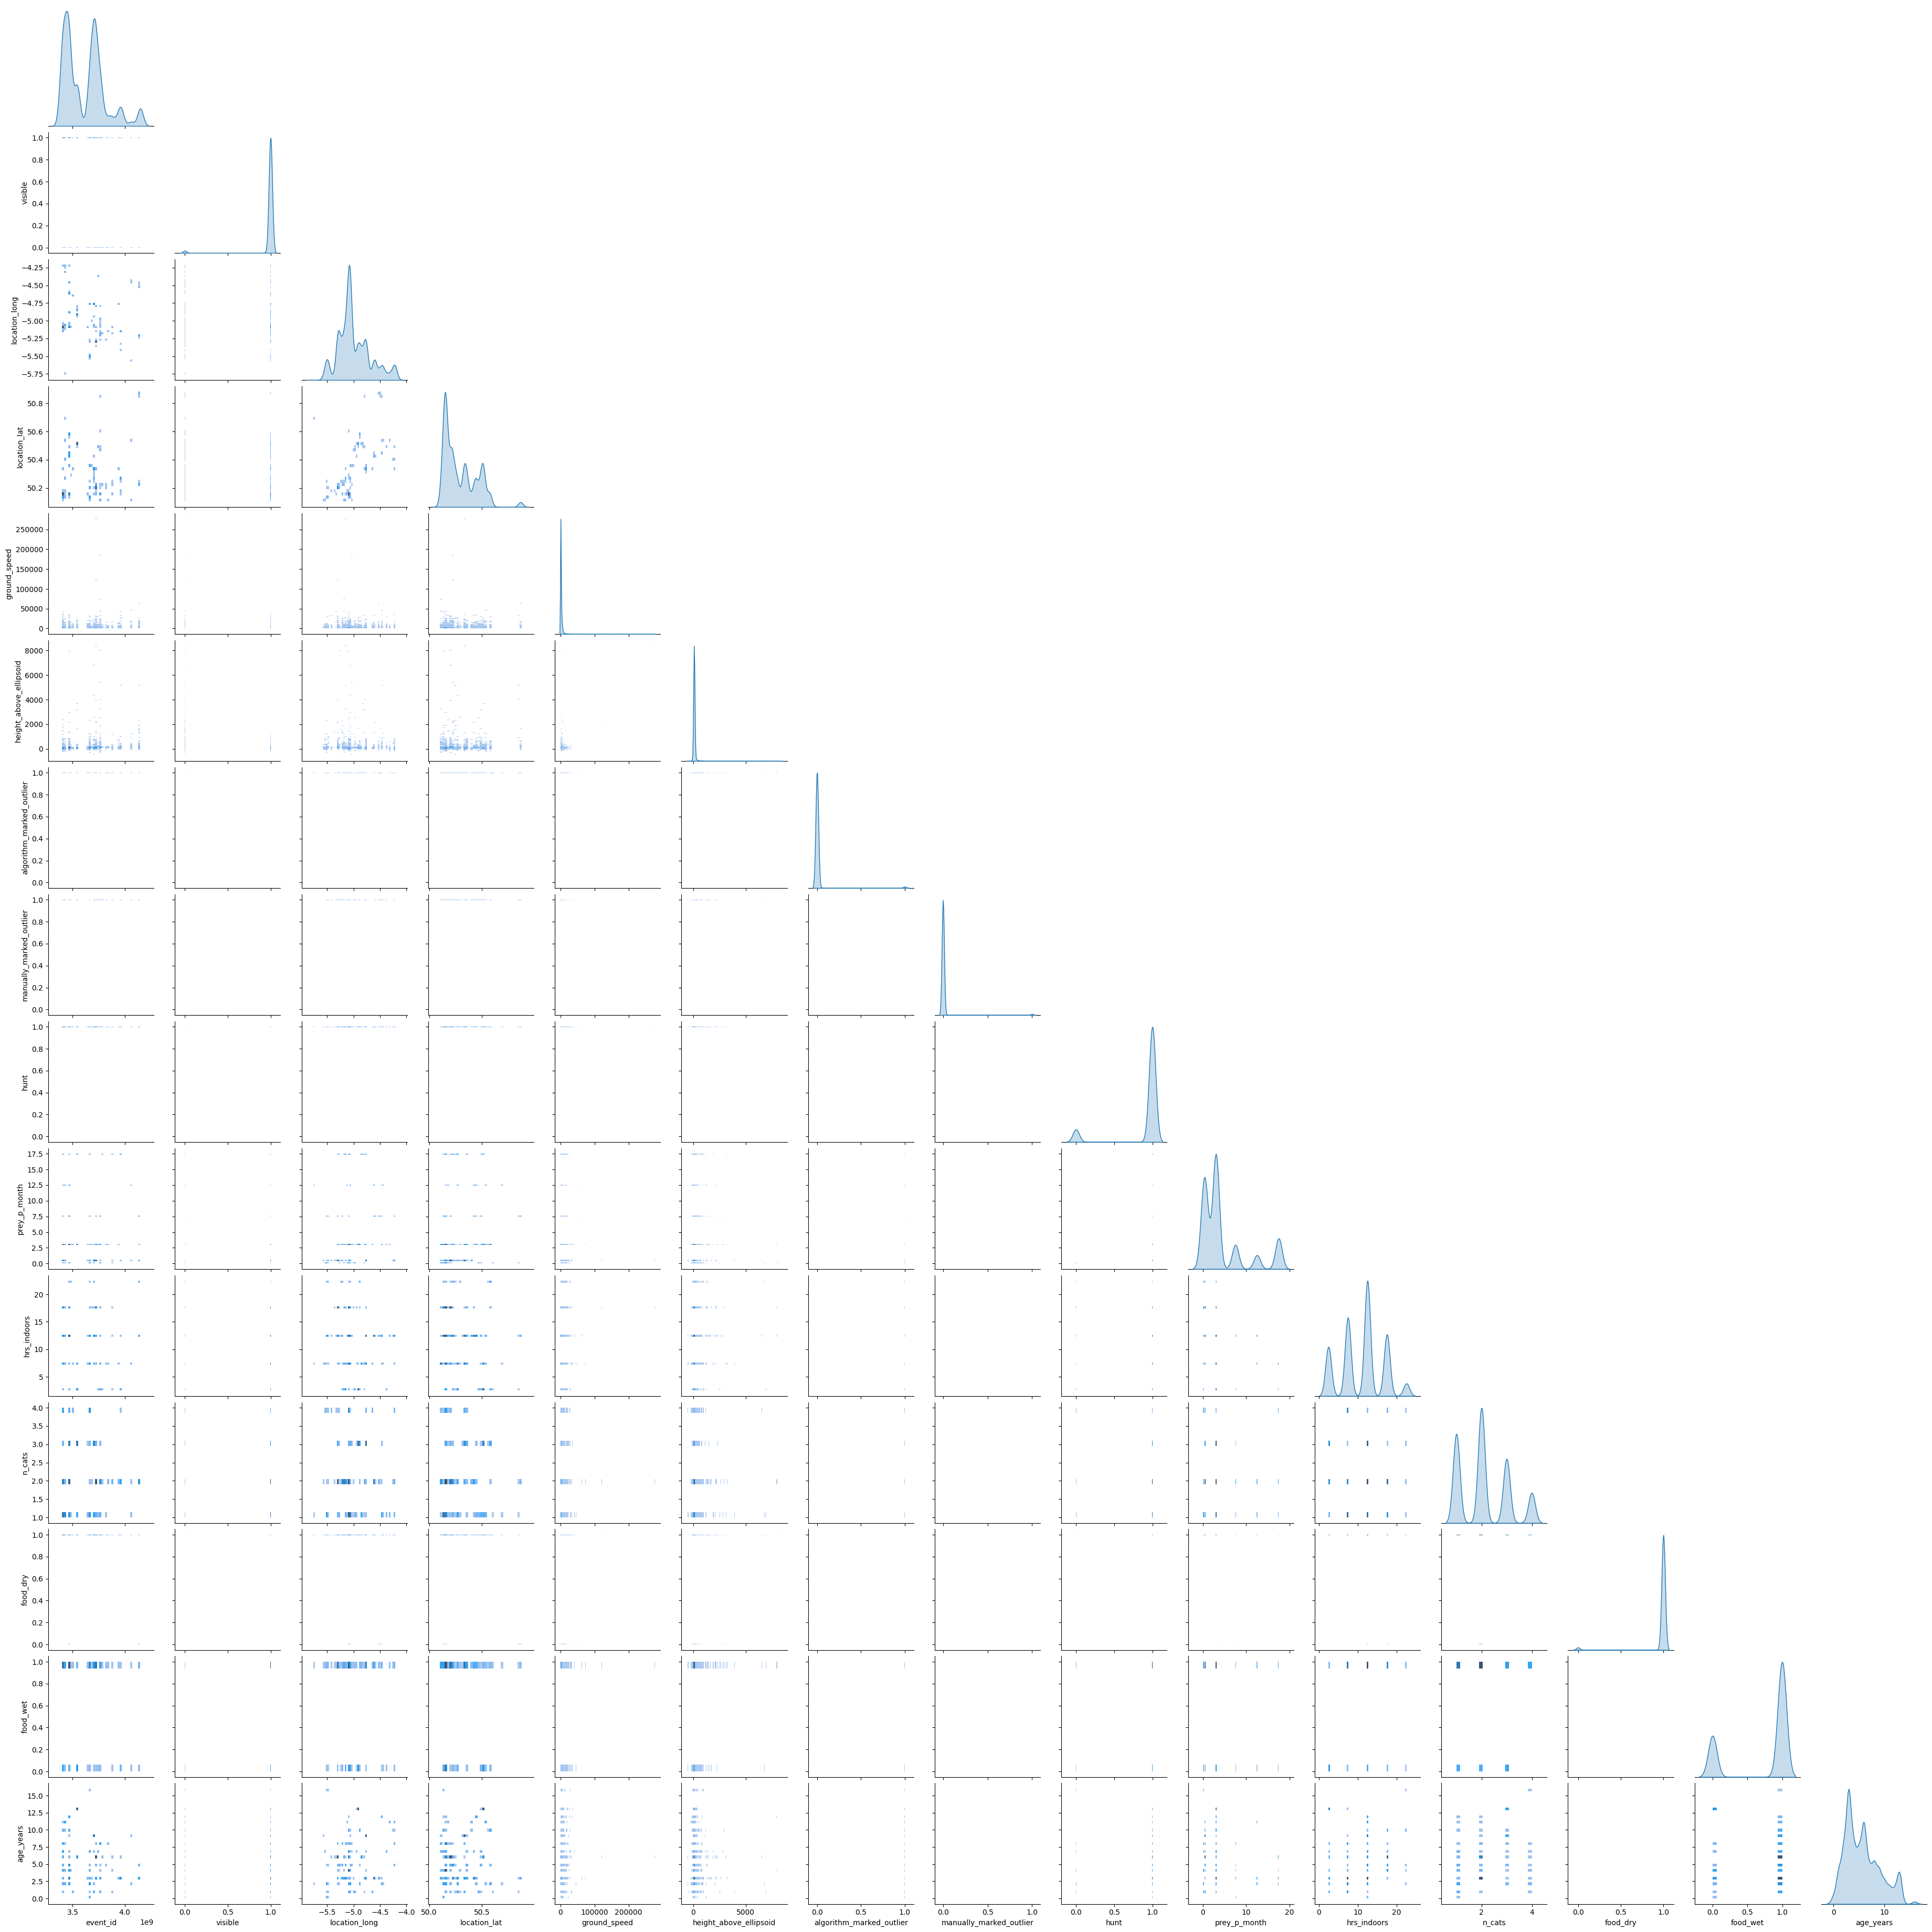

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(cleaned_cats_data, kind="hist", diag_kind="kde", corner=True)

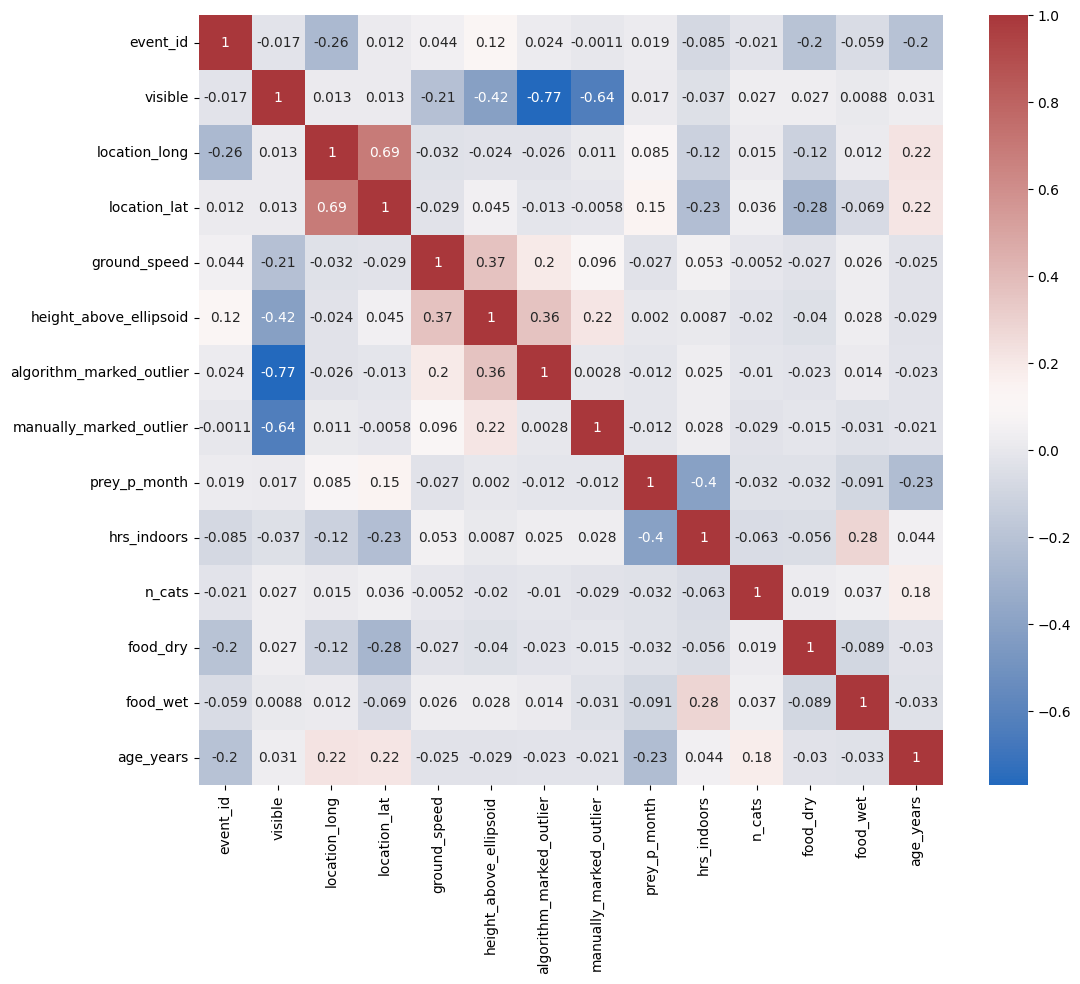

In [ ]:
corr = cleaned_cats_data.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
corr = cleaned_cats_data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="vlag")
plt.show()

The EDA presented above is inherited from Milestone 1 (M1). As it serves as the shared analytical foundation for all subsequent individual analyses, it has been retained without modification to ensure methodological consistency across team members’ work.

## Integrated Pipeline

In [ ]:
# 1) Converts timestamps to UTC datetime and creates time-of-day indicators.
if "timestamp" in cleaned_cats_data.columns:
    cleaned_cats_data["timestamp"] = pd.to_datetime(cleaned_cats_data["timestamp"], errors="coerce", utc=True)
    cleaned_cats_data = cleaned_cats_data.dropna(subset=["timestamp"])
    cleaned_cats_data["hour"] = cleaned_cats_data["timestamp"].dt.hour
    NIGHT_HOURS = [20,21,22,23,0,1,2,3,4,5]
    cleaned_cats_data["is_night"] = cleaned_cats_data["hour"].isin(NIGHT_HOURS).astype(int)

In [ ]:
# 2) Define cat-level
agg_dict = {}

for col in ["location_lat", "location_long"]:
    if col in cleaned_cats_data.columns:
        agg_dict[col] = ["mean", "std"]

if "ground_speed" in cleaned_cats_data.columns:
    cleaned_cats_data["ground_speed"] = pd.to_numeric(cleaned_cats_data["ground_speed"], errors="coerce")
    cleaned_cats_data = cleaned_cats_data.dropna(subset=["ground_speed"])
    agg_dict["ground_speed"] = ["mean", "std", "max", "median", "count"]

if "height_above_ellipsoid" in cleaned_cats_data.columns:
    agg_dict["height_above_ellipsoid"] = ["mean", "std"]

# night_ratio
if "is_night" in cleaned_cats_data.columns:
    agg_dict["is_night"] = ["mean"]

cat_level = cleaned_cats_data.groupby("tag_id").agg(agg_dict)
cat_level.columns = ["_".join([c for c in col if c]) for col in cat_level.columns]
cat_level = cat_level.reset_index()

# rename for readability
cat_level = cat_level.rename(columns={
    "ground_speed_count": "n_points",
    "is_night_mean": "night_ratio"
})

print("cat_level shape:", cat_level.shape)
cat_level.head()

cat_level shape: (88, 13)


,tag_id,location_lat_mean,location_lat_std,location_long_mean,location_long_std,ground_speed_mean,ground_speed_std,ground_speed_max,ground_speed_median,n_points,height_above_ellipsoid_mean,height_above_ellipsoid_std,night_ratio
0,Abba-Tag,50.163311,0.000407,-5.204463,0.001146,1603.951807,2149.160017,13968,864.0,83,177.981566,195.673112,0.614458
1,Alfie-Tag,50.344323,0.000870,-4.759988,0.001753,1931.679144,2413.262206,14652,1188.0,187,82.725668,102.561322,0.481283
2,Athena,50.170166,0.000247,-5.114081,0.000416,2134.188679,2685.603928,19728,1494.0,106,87.520283,44.317564,0.490566
3,Balu-Tag,50.496850,0.000371,-4.377609,0.000644,2004.957055,3201.522966,31140,1260.0,163,162.257055,45.532426,0.822086
4,Barney-Tag,50.406121,0.000408,-4.232356,0.000461,1646.709677,1775.056549,10548,1188.0,155,42.765806,31.022332,0.522581


In [ ]:
# 3) Merge explanatory variables

meta_cols = ["tag_id"]
for c in ["animal_sex", "hrs_indoors", "hunt", "prey_p_month", "n_cats"]:
    if c in cats_meta.columns:
        meta_cols.append(c)

meta = cats_meta[meta_cols].drop_duplicates("tag_id")
cat_level = cat_level.merge(meta, on="tag_id", how="left")

print("cat_level after meta merge:", cat_level.shape)
cat_level.head()


cat_level after meta merge: (88, 18)


,tag_id,location_lat_mean,location_lat_std,location_long_mean,location_long_std,ground_speed_mean,ground_speed_std,ground_speed_max,ground_speed_median,n_points,height_above_ellipsoid_mean,height_above_ellipsoid_std,night_ratio,animal_sex,hrs_indoors,hunt,prey_p_month,n_cats
0,Abba-Tag,50.163311,0.000407,-5.204463,0.001146,1603.951807,2149.160017,13968,864.0,83,177.981566,195.673112,0.614458,f,7.5,True,3.0,2
1,Alfie-Tag,50.344323,0.000870,-4.759988,0.001753,1931.679144,2413.262206,14652,1188.0,187,82.725668,102.561322,0.481283,m,7.5,True,3.0,2
2,Athena,50.170166,0.000247,-5.114081,0.000416,2134.188679,2685.603928,19728,1494.0,106,87.520283,44.317564,0.490566,f,7.5,True,3.0,2
3,Balu-Tag,50.496850,0.000371,-4.377609,0.000644,2004.957055,3201.522966,31140,1260.0,163,162.257055,45.532426,0.822086,f,2.5,True,3.0,1
4,Barney-Tag,50.406121,0.000408,-4.232356,0.000461,1646.709677,1775.056549,10548,1188.0,155,42.765806,31.022332,0.522581,m,12.5,True,0.5,2


In [ ]:
# 4)Define feature set + impute + scale

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

candidate_features = [
    "location_lat_mean", "location_lat_std",
    "location_long_mean", "location_long_std",
    "ground_speed_mean", "ground_speed_std", "ground_speed_max", "ground_speed_median",
    "height_above_ellipsoid_mean", "height_above_ellipsoid_std",
    "n_points", "night_ratio",
    "hrs_indoors", "prey_p_month", "n_cats"
]

feature_cols = [c for c in candidate_features if c in cat_level.columns]
print("Using features:", feature_cols)

X = cat_level[feature_cols].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imp = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imp)

print("X_scaled shape:", X_scaled.shape)

Using features: ['location_lat_mean', 'location_lat_std', 'location_long_mean', 'location_long_std', 'ground_speed_mean', 'ground_speed_std', 'ground_speed_max', 'ground_speed_median', 'height_above_ellipsoid_mean', 'height_above_ellipsoid_std', 'n_points', 'night_ratio', 'hrs_indoors', 'prey_p_month', 'n_cats']
X_scaled shape: (88, 15)


## Unified clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster

k_list = list(range(3, 11))

# KMeans selection
best_k, best_sil, best_model = None, -1, None
k_rows = []
for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    k_rows.append({"k": k, "silhouette": sil, "inertia": km.inertia_})
    if sil > best_sil:
        best_k, best_sil, best_model = k, sil, km

kmeans_eval = pd.DataFrame(k_rows).sort_values("k")
display(kmeans_eval)
print("Best KMeans:", best_k, "sil:", round(best_sil, 4))

labels_km = best_model.fit_predict(X_scaled)

,k,silhouette,inertia
0,3,0.167498,965.426792
1,4,0.180331,845.416690
2,5,0.175865,748.639363
3,6,0.189048,680.666762
4,7,0.186871,632.403485
5,8,0.105220,600.547308
6,9,0.115170,556.557035
7,10,0.156148,520.240693


Best KMeans: 6 sil: 0.189


In [ ]:
# Hierarchical selection
Z = linkage(X_scaled, method="ward")
best_k_h, best_sil_h, best_labels_h = None, -1, None
h_rows = []
for k in k_list:
    labels_h = fcluster(Z, t=k, criterion="maxclust")
    sil_h = silhouette_score(X_scaled, labels_h)
    h_rows.append({"k": k, "silhouette": sil_h})
    if sil_h > best_sil_h:
        best_k_h, best_sil_h, best_labels_h = k, sil_h, labels_h

hier_eval = pd.DataFrame(h_rows).sort_values("k")
display(hier_eval)
print("Best Hier:", best_k_h, "sil:", round(best_sil_h, 4))

,k,silhouette
0,3,0.311252
1,4,0.179182
2,5,0.190344
3,6,0.200794
4,7,0.199492
5,8,0.206877
6,9,0.202251
7,10,0.121169


Best Hier: 3 sil: 0.3113


In [ ]:
ari = adjusted_rand_score(labels_km, best_labels_h)
print("ARI(KMeans vs Hier):", round(ari, 4))

ARI(KMeans vs Hier): 0.2971


In [ ]:
cat_level["cluster_final"] = labels_km
cat_level["cluster_h"] = best_labels_h
cat_level["cluster_final"].value_counts().sort_index()


cluster_final
0    21
1    43
2     9
3    10
4     3
5     2
Name: count, dtype: int64

##Domain / Business Questions

###Question 1

 **Q1 (Refined)**: Do geographic clusters derived from latitude and longitude represent meaningful differences in behavioral intensity, or are they primarily reflecting spatial density without distinct behavioral structure?

**Explain**: In M2, clustering relied only on latitude and longitude, resulting in limited behavioral differentiation and one dominant cluster. Influenced by Kaixin’s M2, which emphasized cat-level behavioral aggregation, M3 shifts the focus from identifying spatial groups to examining whether geographic clustering truly reflects distinct behavior or simply uneven activity density.

**Significance**:

This analysis is important for understanding cats’ living conditions and spatial distribution across urban areas. Policymakers and city councils can use these insights to develop more effective and region-specific animal control policies. Biodiversity conservation groups can also leverage this information to guide member allocation and resource deployment.



In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

geo_cols = [c for c in ["location_lat_mean", "location_long_mean"] if c in cat_level.columns]
print("Geo columns:", geo_cols)

X_geo = cat_level[geo_cols].copy()
X_geo_scaled = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(X_geo))

k_list = list(range(3, 8))

# KMeans
rows = []
best_k, best_sil = None, -1
best_labels_geo = None

for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_geo_scaled)
    sil = silhouette_score(X_geo_scaled, labels)
    rows.append({"method":"kmeans","k":k,"silhouette":sil})
    if sil > best_sil:
        best_k, best_sil, best_labels_geo = k, sil, labels

# Hierarchical
Z_geo = linkage(X_geo_scaled, method="ward")
for k in k_list:
    labels_h = fcluster(Z_geo, t=k, criterion="maxclust")
    sil_h = silhouette_score(X_geo_scaled, labels_h)
    rows.append({"method":"hier","k":k,"silhouette":sil_h})

eval_geo = pd.DataFrame(rows).sort_values(["method","k"])
display(eval_geo)

cat_level["geo_cluster"] = best_labels_geo
print("Best geo kmeans k:", best_k, "sil:", round(best_sil,4))

# Compare geo-only vs integrated structure
ari_geo_vs_integrated = adjusted_rand_score(cat_level["cluster_final"], cat_level["geo_cluster"])
print("ARI(geo_cluster vs cluster_final):", round(ari_geo_vs_integrated, 4))

# Behavior differences across geo clusters
profile_cols = [c for c in ["ground_speed_mean","ground_speed_max","night_ratio","hrs_indoors","prey_p_month"] if c in cat_level.columns]
geo_profile = cat_level.groupby("geo_cluster")[profile_cols].median().round(2)
display(geo_profile)


Geo columns: ['location_lat_mean', 'location_long_mean']


,method,k,silhouette
5,hier,3,0.563714
6,hier,4,0.553635
7,hier,5,0.562340
8,hier,6,0.569485
9,hier,7,0.623796
0,kmeans,3,0.614738
1,kmeans,4,0.542442
2,kmeans,5,0.562586
3,kmeans,6,0.569904
4,kmeans,7,0.630338


Best geo kmeans k: 7 sil: 0.6303
ARI(geo_cluster vs cluster_final): 0.2187


,ground_speed_mean,ground_speed_max,night_ratio,hrs_indoors,prey_p_month
geo_cluster,,,,,
0,1777.17,14652.0,0.48,12.5,3.0
1,1990.49,19620.0,0.60,12.5,3.0
2,1789.94,14868.0,0.56,12.5,3.0
3,2111.23,18180.0,0.51,12.5,0.5
4,1759.02,20808.0,0.67,7.5,3.0
5,1960.76,17748.0,0.49,12.5,3.0
6,3146.20,62568.0,0.39,12.5,7.5


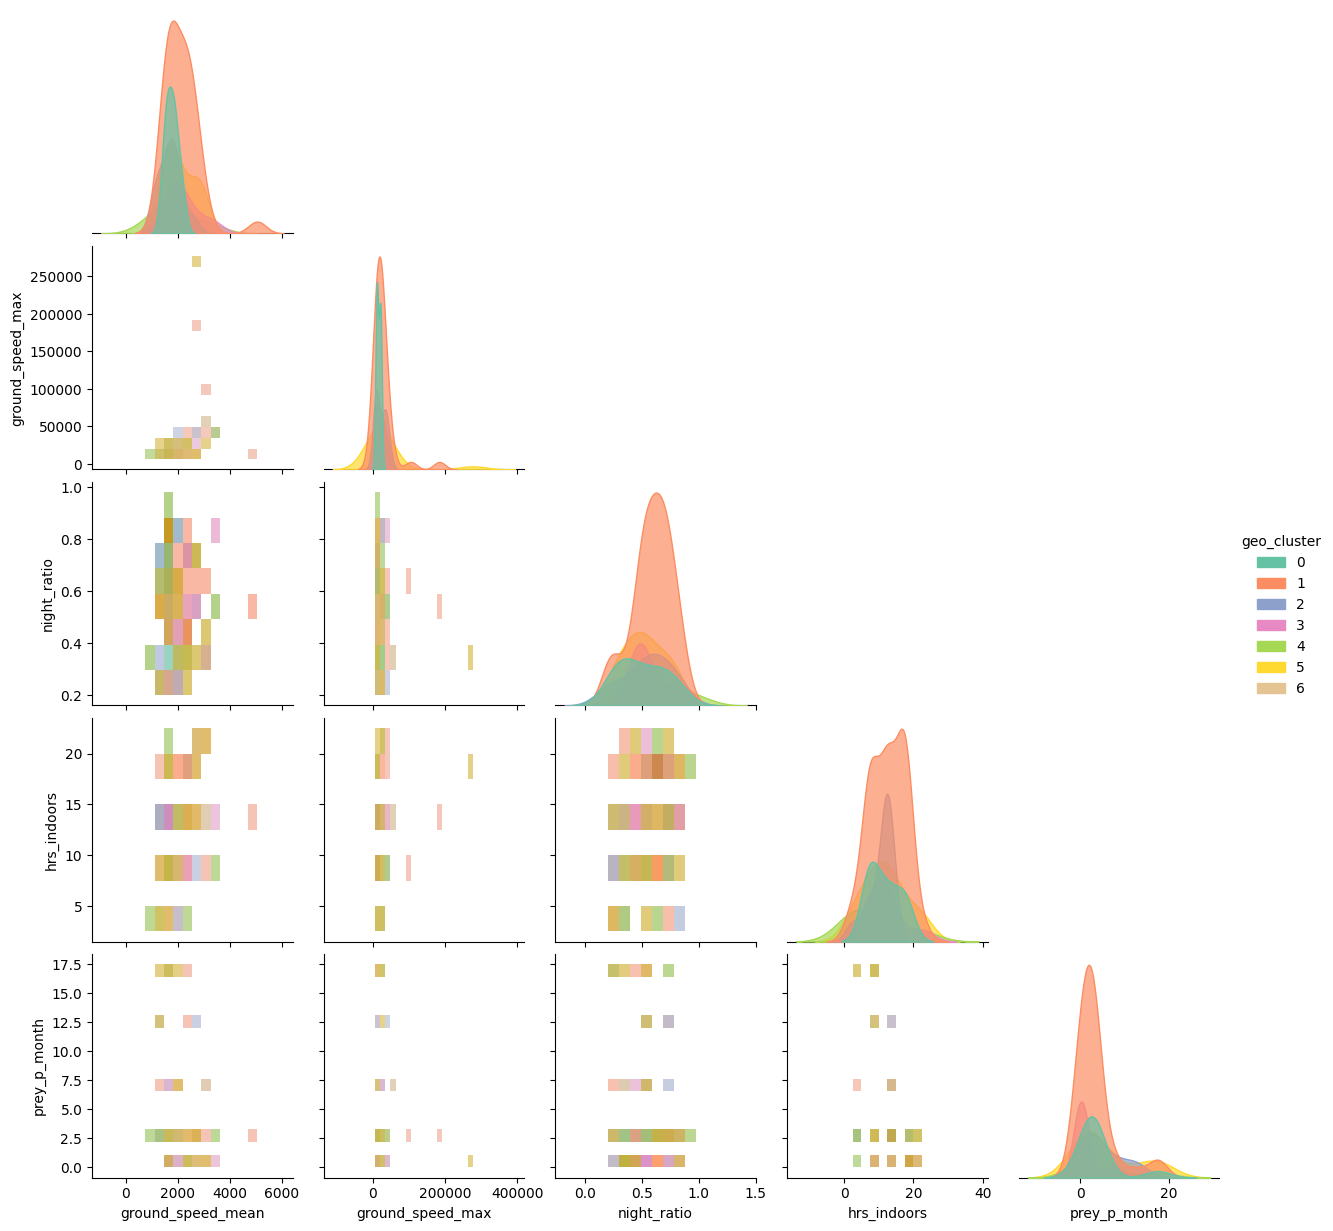

In [ ]:
import seaborn as sns
sns.pairplot(
    cat_level[profile_cols+ ["geo_cluster"]],
    hue="geo_cluster",
    kind="hist",
    diag_kind="kde",
    corner=True,
    palette="Set2",
    plot_kws={'alpha': 0.7},
    diag_kws={'alpha': 0.7}
)


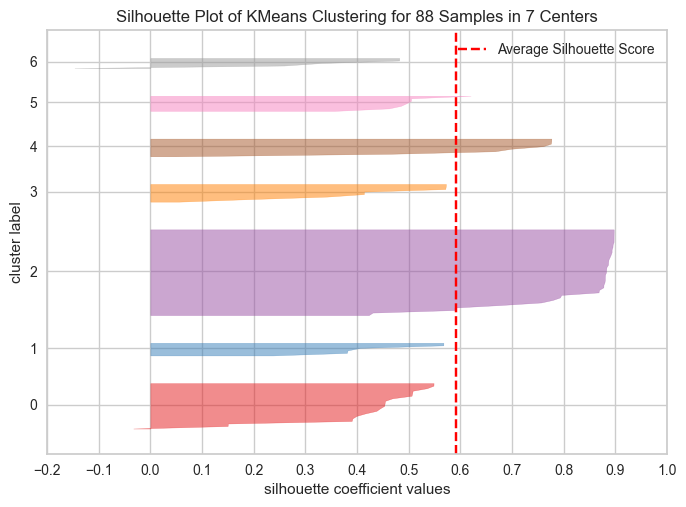

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 88 Samples in 7 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(best_k, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_geo_scaled)
visualizer.show()

In [ ]:
# Q1 extension: DBSCAN + size/stability checks + outlier diagnostics
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

geo_cols = [c for c in ["location_lat_mean", "location_long_mean"] if c in cat_level.columns]
if len(geo_cols) < 2:
    raise ValueError("Need both location_lat_mean and location_long_mean in cat_level for Q1 extension.")

X_geo = cat_level[geo_cols].copy()
X_geo_scaled_db = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(X_geo))


# DBSCAN

db_rows = []
eps_grid = np.round(np.arange(0.20, 1.51, 0.05), 2)
min_samples_grid = [3, 4, 5, 6]

best_labels_db = None
best_row = None
best_score = -np.inf

for eps in eps_grid:
    for ms in min_samples_grid:
        labels = DBSCAN(eps=float(eps), min_samples=int(ms)).fit_predict(X_geo_scaled_db)
        noise_mask = labels == -1
        noise_ratio = float(noise_mask.mean())
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        sil = np.nan
        sil_adj = np.nan
        if n_clusters >= 2 and (~noise_mask).sum() > 2:
            sil = silhouette_score(X_geo_scaled_db[~noise_mask], labels[~noise_mask])
            sil_adj = sil * (1.0 - noise_ratio)

        row = {
            "eps": float(eps),
            "min_samples": int(ms),
            "n_clusters": int(n_clusters),
            "noise_ratio": noise_ratio,
            "silhouette": sil,
            "silhouette_adj": sil_adj,
        }
        db_rows.append(row)


db_eval = pd.DataFrame(db_rows).sort_values("silhouette_adj", ascending=False)
print("Top DBSCAN configs (sorted by silhouette_adj = silhouette * (1-noise_ratio)):")
display(db_eval.head(12))


# Cluster size checks

print("KMeans geo_cluster sizes:")
km_sizes = cat_level["geo_cluster"].value_counts().sort_index()
display(pd.DataFrame({"size": km_sizes, "pct": (100 * km_sizes / len(cat_level)).round(2)}))


print("DBSCAN geo_cluster_dbscan sizes (-1 = outlier/noise):")
db_sizes = cat_level["geo_cluster_dbscan"].value_counts().sort_index()
display(pd.DataFrame({"size": db_sizes, "pct": (100 * db_sizes / len(cat_level)).round(2)}))


#  Stability checks


if best_row is not None:
    base_labels = cat_level["geo_cluster_dbscan"].to_numpy()
    eps0 = float(best_row["eps"])
    ms0 = int(best_row["min_samples"])
    local = []

    for d in [-0.08, -0.05, -0.03, 0.03, 0.05, 0.08]:
        eps_test = round(max(0.05, eps0 + d), 2)
        test_labels = DBSCAN(eps=eps_test, min_samples=ms0).fit_predict(X_geo_scaled_db)
        overlap = (base_labels != -1) & (test_labels != -1)

        if overlap.sum() > 2 and len(np.unique(base_labels[overlap])) > 1 and len(np.unique(test_labels[overlap])) > 1:
            local.append({
                "eps_test": eps_test,
                "overlap_n": int(overlap.sum()),
                "ari_vs_best": adjusted_rand_score(base_labels[overlap], test_labels[overlap]),
            })

    if local:
        print("DBSCAN local-eps stability around best config:")
        display(pd.DataFrame(local).sort_values("eps_test"))


# Outlier diagnostics

profile_cols = ["ground_speed_mean", "ground_speed_max", "night_ratio", "hrs_indoors", "prey_p_month"]


print("Behavior profile by DBSCAN cluster (median):")
display(cat_level.groupby("geo_cluster_dbscan")[profile_cols].median().round(2))

outlier_flag = cat_level["geo_cluster_dbscan"] == -1
print("Outlier/noise vs non-outlier median behavior:")
display(
    cat_level.groupby(outlier_flag)[profile_cols]
    .median()
    .round(2)
    .rename(index={False: "non_outlier", True: "outlier_noise"})
    )

valid = cat_level["geo_cluster_dbscan"] != -1
if valid.sum() > 2 and cat_level.loc[valid, "geo_cluster_dbscan"].nunique() > 1:
    ari_db = adjusted_rand_score(cat_level.loc[valid, "cluster_final"], cat_level.loc[valid, "geo_cluster_dbscan"])
    print("ARI(dbscan_non_noise vs cluster_final):", round(ari_db, 4))



Top DBSCAN configs (sorted by silhouette_adj = silhouette * (1-noise_ratio)):


,eps,min_samples,n_clusters,noise_ratio,silhouette,silhouette_adj
12,0.35,3,9,0.125000,0.690348,0.604054
21,0.45,4,4,0.113636,0.675202,0.598474
22,0.45,5,4,0.136364,0.689465,0.595447
26,0.50,5,4,0.079545,0.641121,0.590122
4,0.25,3,7,0.238636,0.765084,0.582507
8,0.30,3,7,0.193182,0.717442,0.578845
25,0.50,4,4,0.045455,0.605271,0.577758
24,0.50,3,4,0.045455,0.605271,0.577758
31,0.55,6,4,0.045455,0.605271,0.577758
16,0.40,3,7,0.068182,0.612540,0.570776


KMeans geo_cluster sizes:


,size,pct
geo_cluster,,
0,11,12.50
1,35,39.77
2,11,12.50
3,8,9.09
4,7,7.95
5,15,17.05
6,1,1.14


DBSCAN geo_cluster_dbscan sizes (-1 = outlier/noise):


...

Behavior profile by DBSCAN cluster (median):


,ground_speed_mean,ground_speed_max,night_ratio,hrs_indoors,prey_p_month
geo_cluster_dbscan,,,,,
-1,1646.71,11448.0,0.54,12.5,3.0
0,1990.49,19620.0,0.60,12.5,3.0
1,1879.92,18000.0,0.37,7.5,3.0
2,2004.96,31140.0,0.56,7.5,3.0
3,2105.82,26640.0,0.47,5.0,3.0
4,2025.77,12924.0,0.46,12.5,0.0
5,1960.76,17748.0,0.49,12.5,3.0
6,2225.00,31680.0,0.53,12.5,0.5
7,1777.17,18828.0,0.75,12.5,3.0


Outlier/noise vs non-outlier median behavior:


,ground_speed_mean,ground_speed_max,night_ratio,hrs_indoors,prey_p_month
geo_cluster_dbscan,,,,,
non_outlier,1931.68,18900.0,0.56,12.5,3.0
outlier_noise,1646.71,11448.0,0.54,12.5,3.0


ARI(dbscan_non_noise vs cluster_final): 0.1913


In [ ]:
from sklearn.metrics import adjusted_rand_score


mask_non_noise = cat_level["geo_cluster_dbscan"] != -1

ari_db_vs_integrated = adjusted_rand_score(
    cat_level.loc[mask_non_noise, "cluster_final"],
    cat_level.loc[mask_non_noise, "geo_cluster_dbscan"],
)
print("ARI(dbscan_non_noise vs cluster_final):", round(ari_db_vs_integrated, 4))


overlap = cat_level["geo_cluster_dbscan"] != -1

ari_km_vs_db = adjusted_rand_score(
        cat_level.loc[overlap, "geo_cluster"],
        cat_level.loc[overlap, "geo_cluster_dbscan"],
    )
print("ARI(geo_kmeans vs dbscan_non_noise):", round(ari_km_vs_db, 4))



ARI(dbscan_non_noise vs cluster_final): 0.1913
ARI(geo_kmeans vs dbscan_non_noise): 0.9602


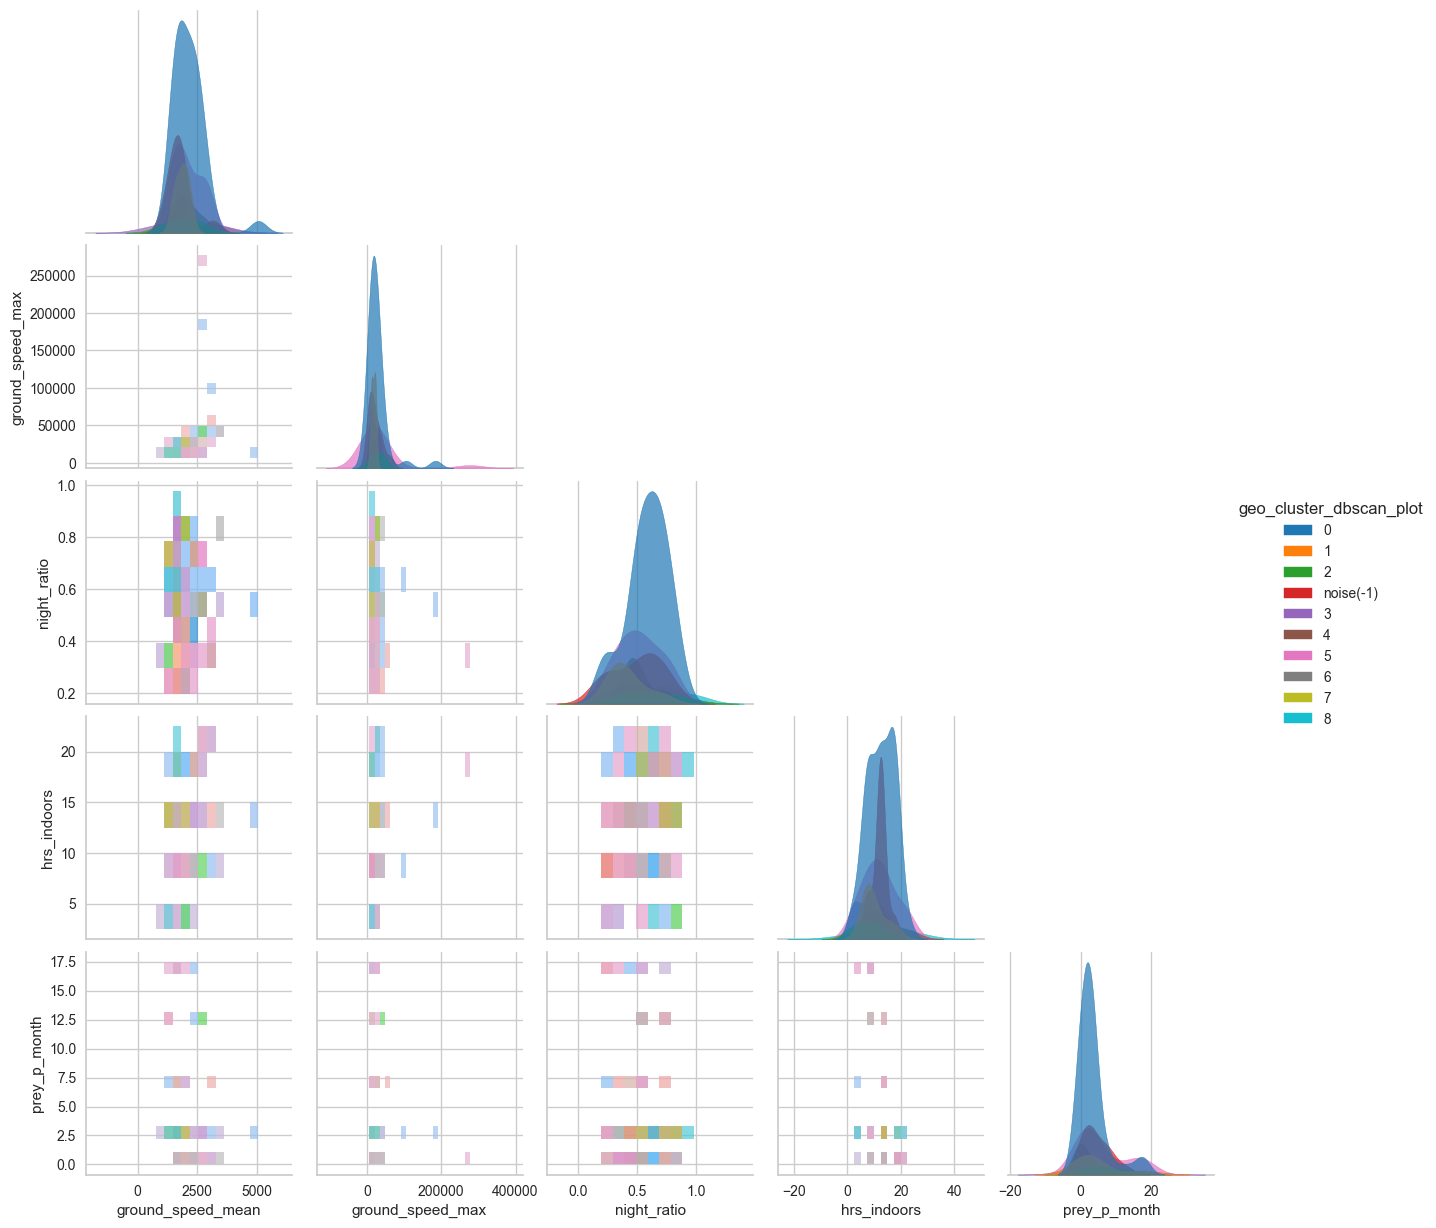

In [ ]:
import matplotlib.pyplot as plt

plot_df = cat_level[profile_cols + ["geo_cluster_dbscan"]].dropna().copy()
plot_df["geo_cluster_dbscan_plot"] = plot_df["geo_cluster_dbscan"].astype(int).astype(str)
plot_df.loc[plot_df["geo_cluster_dbscan"] == -1, "geo_cluster_dbscan_plot"] = "noise(-1)"

sns.pairplot(
    plot_df[profile_cols + ["geo_cluster_dbscan_plot"]],
    hue="geo_cluster_dbscan_plot",
    kind="hist",
    diag_kind="kde",
    corner=True,
    palette="tab10",
    plot_kws={"alpha": 0.7},
    diag_kws={"alpha": 0.7},
)
plt.show()


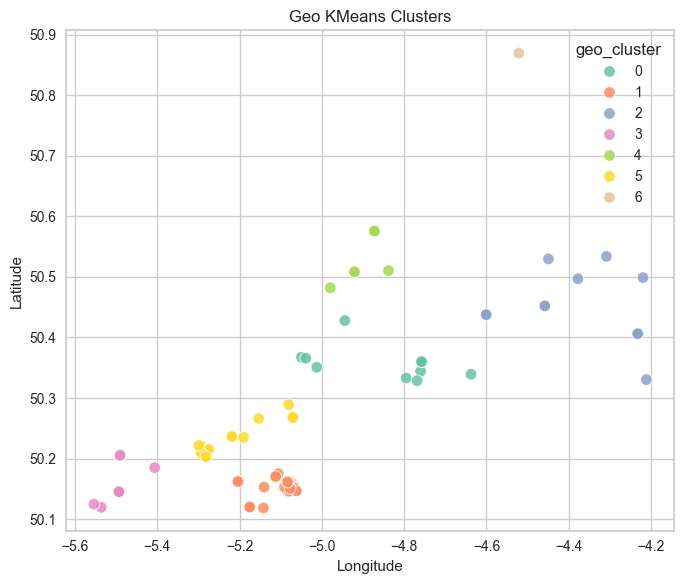

In [ ]:

import matplotlib.pyplot as plt

plot_cols = ["location_long_mean", "location_lat_mean", "geo_cluster"]
plot_df = cat_level[plot_cols].dropna().copy()

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=plot_df,
    x="location_long_mean",
    y="location_lat_mean",
    hue="geo_cluster",
    palette="Set2",
    s=70,
    alpha=0.85,
)
plt.title("Geo KMeans Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()



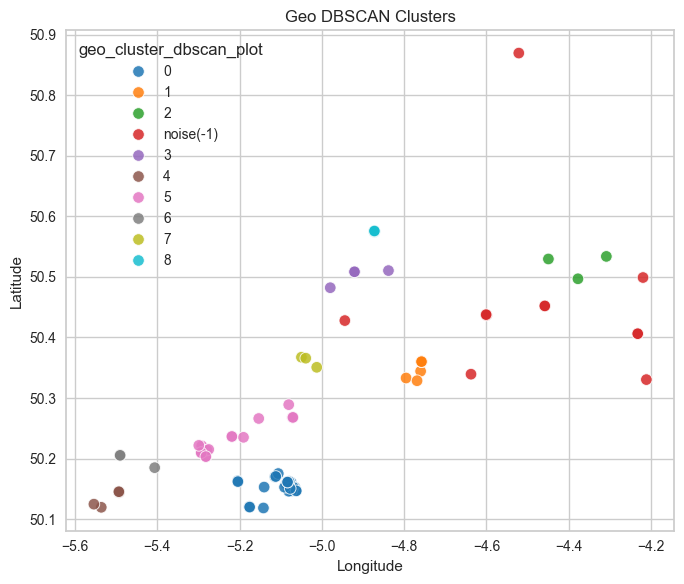

In [ ]:
import matplotlib.pyplot as plt

plot_cols = ["location_long_mean", "location_lat_mean", "geo_cluster_dbscan"]
db_plot = cat_level[plot_cols].dropna().copy()
db_plot["geo_cluster_dbscan_plot"] = db_plot["geo_cluster_dbscan"].astype(int).astype(str)
db_plot.loc[db_plot["geo_cluster_dbscan"] == -1, "geo_cluster_dbscan_plot"] = "noise(-1)"

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=db_plot,
    x="location_long_mean",
    y="location_lat_mean",
    hue="geo_cluster_dbscan_plot",
    palette="tab10",
    s=70,
    alpha=0.85,
)
plt.title("Geo DBSCAN Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


## AI Disclosure





*   Add Comments
*   Coding Aid (part)
*   Text Revision
*   Project Initial Brainstorm
*   Formatting


ChatGPT Link:
https://chatgpt.com/share/699a397b-2aa4-8013-8d32-7635985cf1f0



